# Deep Neural Network - Baseline - > Regularization

In [56]:
! pip install pandas matplotlib seaborn

In [57]:
# import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras


In [59]:
import torch

In [60]:
# check for GPU
print(torch.cuda.is_available())


False


In [61]:
# no GPU - by default is CPU
tf.config.list_physical_devices('GPU')

[]

In [62]:
# recheck GPU
tf.test.gpu_device_name()

''

In [63]:
# pytorch
import torch
torch.cuda.is_available()

False

In [64]:
# device name
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


## 1. load the data


In [65]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
# print shape
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
# see one image
X_train[0]

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

## 2. Preprocess the data

In [66]:
# flatten - mandatory
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

# shape
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
#

(60000, 784) (60000,) (10000, 784) (10000,)


In [67]:
# normalization - optional
X_train = X_train / 255.0
X_test = X_test / 255.0

# check for one-input
X_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

## 3. Building a Simple ANN/DNN

- 784 = input-features(no neurons)
- 128 = hidden-layer neurons
- 10  = output neurons/classes

In [68]:

simple_dnn = keras.models.Sequential(name="Baseline")

# layers
simple_dnn.add(keras.layers.Dense(units=128, activation='relu', input_shape=(784,)))
simple_dnn.add(keras.layers.Dense(units=10, activation='softmax'))

simple_dnn.summary()

Model: "Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

- **Width : neurons in a layer =             128,10**
- **Depth : number of hidden layers =          1**

In [81]:
# complile
# compile
simple_dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# fit
simple_dnn.fit(X_train, y_train, epochs=50, batch_size = 128, validation_split=0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 936us/step - accuracy: 0.9265 - loss: 0.1998 - val_accuracy: 0.8898 - val_loss: 0.3152
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - accuracy: 0.9289 - loss: 0.1936 - val_accuracy: 0.8870 - val_loss: 0.3378
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step - accuracy: 0.9305 - loss: 0.1915 - val_accuracy: 0.8920 - val_loss: 0.3222
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - accuracy: 0.9315 - loss: 0.1859 - val_accuracy: 0.8890 - val_loss: 0.3286
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.9314 - loss: 0.1837 - val_accuracy: 0.8916 - val_loss: 0.3177
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - accuracy: 0.9335 - loss: 0.1807 - val_accuracy: 0.8907 - val_loss: 0.3284
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - accuracy: 0.9348 - loss: 0.1751 - val_accuracy: 0.8894 - val_loss: 0.3243
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - accuracy: 0.9373 - loss: 0.1691 - 

In [82]:
#test
simple_dnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - accuracy: 0.8857 - loss: 0.5037


[0.5036545991897583, 0.885699987411499]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 319us/step - accuracy: 0.8857 - loss: 0.5037


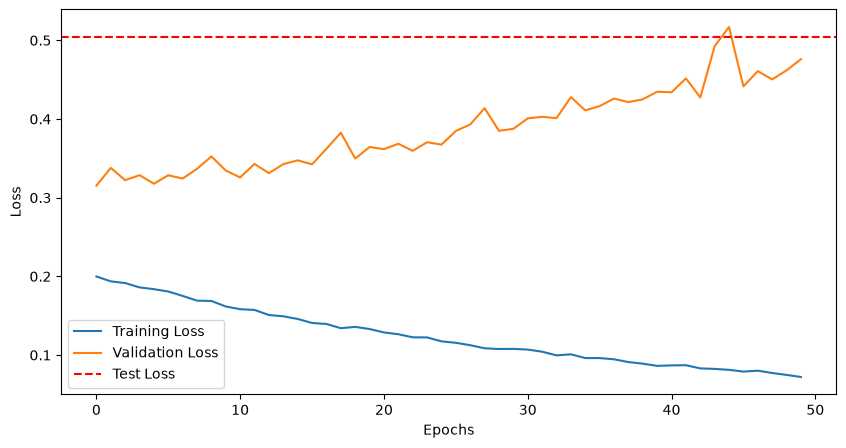

In [83]:
# detection of Overfitting - Training vs Validation vs Test Loss
plt.figure(figsize=(10,5))
plt.plot(simple_dnn.history.history['loss'], label='Training Loss')
plt.plot(simple_dnn.history.history['val_loss'], label='Validation Loss')
plt.axhline(simple_dnn.evaluate(X_test, y_test)[0], color='red', linestyle='--', label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### Observations-
- `Classic Overfitting pattern` :  Training is reducing loss metric while Validation has reached a stale point.
- `No Generalization` : Testing has shown that no further than 3rd Epoch result is being learnt by moidel.

## Regularization

### Early Stopping
`monitor = 'val_loss`

In [84]:
early_stop = keras.callbacks.EarlyStopping(
                                          monitor='val_loss',
                                          patience=5,
                                          restore_best_weights=True)

In [85]:
# model
early_model = keras.Sequential(name="Early_Stopping")
early_model.add(keras.layers.Dense(units=128, activation='relu', input_shape=(784,)))
early_model.add(keras.layers.Dense(units=10, activation='softmax'))
early_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# fit
early_model.fit(X_train, y_train, epochs=20, batch_size=128,
                validation_split=0.2,
                callbacks=[early_stop])

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step - accuracy: 0.8023 - loss: 0.5783 - val_accuracy: 0.8289 - val_loss: 0.4831
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step - accuracy: 0.8543 - loss: 0.4186 - val_accuracy: 0.8607 - val_loss: 0.3972
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - accuracy: 0.8677 - loss: 0.3748 - val_accuracy: 0.8614 - val_loss: 0.3842
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - accuracy: 0.8769 - loss: 0.3483 - val_accuracy: 0.8717 - val_loss: 0.3584
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - accuracy: 0.8837 - loss: 0.3232 - val_accuracy: 0.8787 - val_loss: 0.3374
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.8869 - loss: 0.3088 - val_accuracy: 0.8757 - val_loss: 0.3494
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - accuracy: 0.8947 - loss: 0.2942 - val_accuracy: 0.8767 - val_loss: 0.3417
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step - accuracy: 0.8952 - loss: 0.2847 - 

Stopped @ Epoch : 12, after waiting for next 5 epochs in patience.

In [86]:
# best paramters as per EarlyStopping
test_acc, test_loss = early_model.evaluate(X_test, y_test)

# find the epoch number and validation accuracy
print("Minimum validation loss : ",min(early_model.history.history['val_loss']))

print("Test Loss @ best_params / lowest_val_loss :", test_loss)
print("Test Accuracy @ best_params / lowest_val_loss :", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step - accuracy: 0.8857 - loss: 0.3362
Minimum validation loss :  0.31044554710388184
Test Loss @ best_params / lowest_val_loss : 0.885699987411499
Test Accuracy @ best_params / lowest_val_loss : 0.3362480700016022


**`Observation` : Early Stopping reduced training time, got the best parameter state that produced least validation error.**


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step - accuracy: 0.8857 - loss: 0.3362


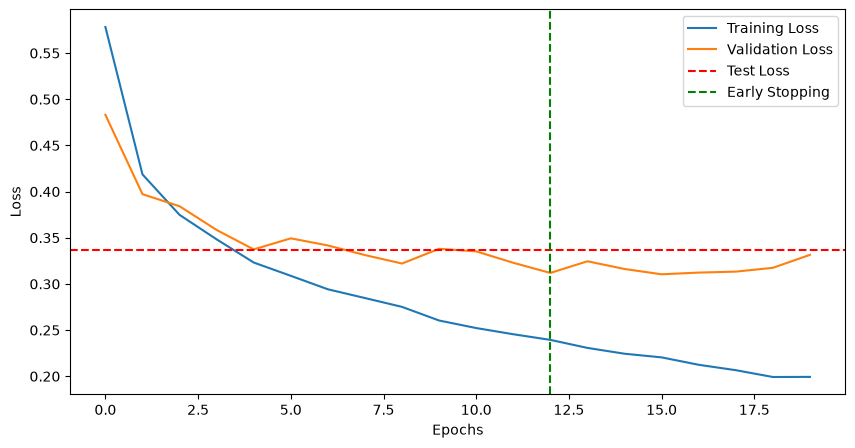

In [ ]:
# plot this loss of train,test,validation
plt.figure(figsize=(10,5))
plt.plot(early_model.history.history['loss'], label='Training Loss')
plt.plot(early_model.history.history['val_loss'], label='Validation Loss')
plt.axhline(early_model.evaluate(X_test, y_test)[0], color='red', linestyle='--', label='Test Loss')
plt.axvline(x=12, color='green', linestyle='--', label='Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Regularization with L2 - Ridge / Weight Decay

$ Loss_R = Loss_o + λ . ∑W^2$

In [88]:
l2_model = keras.Sequential(name="L2_Regularization")

l2_model.add(keras.layers.Dense(units = 128, activation='relu', input_shape=(784,),
             kernel_regularizer=keras.regularizers.l2(0.01)))

l2_model.add(keras.layers.Dense(units = 10, activation='softmax'))

In [89]:
l2_model.summary()

Model: "L2_Regularization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
# weights
for layer in l2_model.layers:
    weights, biases = layer.get_weights()
    print(weights.shape)
    print(biases.shape)

    print(weights[:1])
    print(biases[:1])

(784, 128)
(128,)
[[ 0.06383453  0.01945191 -0.06538472  0.045586    0.03280105  0.04612028
   0.02193215  0.03613497  0.03400352 -0.00520875  0.07712808  0.0540724
  -0.06623168  0.02653669  0.0368382  -0.07036179  0.05306246 -0.03909676
   0.06050161 -0.06109454 -0.04366023 -0.00182205  0.02686366  0.05217672
  -0.00846227  0.07080109 -0.06169767 -0.03654623 -0.03671287  0.01933756
  -0.03074262 -0.01249856 -0.0521038   0.0371884   0.0444316  -0.01901483
   0.06463806 -0.03073318  0.07730251 -0.02283987  0.0718301  -0.07056617
   0.080333    0.03831869 -0.06647268  0.07887378  0.04025039 -0.08098095
   0.03179751  0.01648145  0.07427286 -0.06630291 -0.07937627  0.07202763
   0.05522283 -0.06197759  0.01574132 -0.03415055 -0.07454333 -0.02624524
   0.01201887  0.05615527 -0.07253817  0.07906549 -0.07916334  0.07469762
  -0.01126402  0.05448357 -0.06559052  0.00344002  0.01847398  0.01846997
  -0.06743336 -0.03142255 -0.04874464  0.06014315  0.07042751  0.0668169
   0.06887869  0.07866

In [91]:
# compile
l2_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# fit
l2_model.fit(X_train,y_train, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7874 - loss: 1.2095 - val_accuracy: 0.8262 - val_loss: 0.6957
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - accuracy: 0.8249 - loss: 0.6443 - val_accuracy: 0.8163 - val_loss: 0.6224
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.8258 - loss: 0.6052 - val_accuracy: 0.8183 - val_loss: 0.5939
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - accuracy: 0.8325 - loss: 0.5784 - val_accuracy: 0.8334 - val_loss: 0.5738
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - accuracy: 0.8358 - loss: 0.5683 - val_accuracy: 0.8294 - val_loss: 0.5682
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step - accuracy: 0.8338 - loss: 0.5641 - val_accuracy: 0.8343 - val_loss: 0.5653
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - accuracy: 0.8380 - loss: 0.5555 - val_accuracy: 0.8418 - val_loss: 0.5409
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - accuracy: 0.8406 - loss: 0.5412 - va

In [92]:
# evaluate
l2_model.evaluate(X_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - accuracy: 0.8467 - loss: 0.5133


[0.5133274793624878, 0.8467000126838684]

**Loss is more becasue penalty is larger @ 0.01, we can reduce it further for better loss/accuracy**

In [93]:
# weights
for layer in l2_model.layers:
    weights, biases = layer.get_weights()
    print(weights.shape)
    print(biases.shape)

    print(weights[:1])
    print(biases[:1])

(784, 128)
(128,)
[[ 7.80605536e-04 -1.03623851e-03 -5.91049556e-08  1.49808438e-05
   1.17861677e-03 -1.23576808e-03  1.06836844e-03  4.34949674e-04
  -2.12343593e-07  2.36272911e-07  7.14835222e-12  6.61610102e-06
   6.08363793e-12  1.71998494e-07 -1.98102236e-04  7.40789052e-04
  -6.35012228e-04  7.22592750e-11  5.00412170e-07  4.32391460e-07
   1.25164376e-03 -4.52222962e-34 -7.64289114e-04  1.71576772e-07
   3.10796298e-34 -1.52047605e-07 -3.62204098e-08  1.44828177e-11
   1.15892058e-03  4.73534528e-05  3.52875531e-07  9.90274013e-04
   1.52427447e-06 -2.81193752e-06 -4.19970725e-08 -2.76454921e-06
   5.48178589e-35  5.67876268e-04 -4.95812905e-11  2.50909016e-12
  -1.01775897e-03 -6.74938725e-04 -1.80750518e-04 -7.39298206e-12
   1.24481656e-33 -2.29110411e-11 -2.26126930e-12  2.99990717e-08
   1.88106664e-09  1.13693915e-10  9.23101595e-10 -1.24380182e-04
  -2.72096637e-35 -4.53118380e-04  9.71957045e-35 -1.33277557e-03
   2.29274278e-07 -1.87929021e-04  3.61829859e-15 -8.93710

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 304us/step - accuracy: 0.8467 - loss: 0.5133


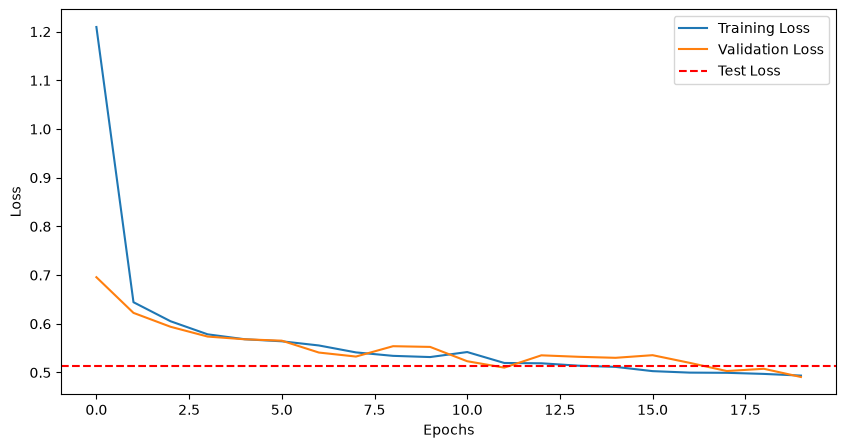

In [94]:
# plot
plt.figure(figsize=(10,5))
plt.plot(l2_model.history.history['loss'], label='Training Loss')
plt.plot(l2_model.history.history['val_loss'], label='Validation Loss')
plt.axhline(l2_model.evaluate(X_test, y_test)[0], color='red', linestyle='--', label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Multi - layer A

### Reguarization with Dropouts

In [ ]:
dropout_model = keras.Sequential(name="Dropout_Regularization")

dropout_model.add(keras.layers.Dense(units = 128, activation='relu', input_shape=(784,)))
dropout_model.add(keras.layers.Dropout(0.3))

dropout_model.add(keras.layers.Dense(units = 10, activation='softmax'))

dropout_model.summary()



In [ ]:
# compile
dropout_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# fit
dropout_model.fit(X_train,y_train, epochs=20, batch_size=128, validation_split=0.2)

In [ ]:
# MODEL EVALUATE
dropout_model.evaluate(X_test, y_test)

In [ ]:
# PLOT THEM
plt.figure(figsize=(10,5))
plt.plot(dropout_model.history.history['loss'], label='Training Loss')
plt.plot(dropout_model.history.history['val_loss'], label='Validation Loss')
plt.axhline(dropout_model.evaluate(X_test, y_test)[0], color='red', linestyle='--', label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
#

## APPROACH TO MAKE MULTIPLE LAYERS WITH SAME NEURONS (128)
64->32->32


In [ ]:
# MULTI-LAYER MODEL
ann_model = keras.Sequential(name="Multi_Layer_Model")

ann_model.add(keras.layers.Dense(units = 64, activation='relu', input_shape=(784,)))
ann_model.add(keras.layers.Dense(units = 32, activation='relu'))
ann_model.add(keras.layers.Dense(units = 32, activation='relu'))

ann_model.add(keras.layers.Dense(units = 10, activation='softmax'))

ann_model.summary()

In [ ]:
# complile
ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# fit
ann_model.fit(X_train,y_train, epochs=20, batch_size=128, validation_split=0.2)

In [ ]:
# evaluate
ann_model.evaluate(X_test, y_test)